In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Grafiklerin notebook içinde görünmesi için
%matplotlib inline

BASE_PATH = r"../dataset"
CLASSES = ['Rook', 'Queen', 'Pawn', 'Knight', 'King', 'Bishop']

print("Kütüphaneler yüklendi ve sınıflar tanımlandı.")

Kütüphaneler yüklendi ve sınıflar tanımlandı.


In [12]:
data_list = []

for c in CLASSES:
    class_path = os.path.join(BASE_PATH, c)
    if not os.path.exists(class_path):
        print(f"Hata: {c} klasörü bulunamadı!")
        continue
        
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                file_size = os.path.getsize(img_path) / 1024  # KB cinsinden
                data_list.append([c, img_name, width, height, file_size, img.mode])
        except Exception as e:
            # Okunamayan dosyaları 'None' olarak işaretliyoruz (Eksik veri analizi için)
            data_list.append([c, img_name, None, None, None, None])


df = pd.DataFrame(data_list, columns=['Sınıf', 'Dosya_Adi', 'Genislik', 'Yukseklik', 'Boyut_KB', 'Mod'])
print("Veri tarama tamamlandı. Rastgele 10 örnek:")
df.sample(10)

Veri tarama tamamlandı. Rastgele 10 örnek:


,Sınıf,Dosya_Adi,Genislik,Yukseklik,Boyut_KB,Mod
1575,King,70.jpeg,275,183,7.200195,RGB
304,Rook,80.jpeg,225,225,4.107422,RGB
1105,Knight,219.jpeg,225,225,3.730469,RGB
1827,Bishop,39.jpeg,225,225,2.780273,RGB
1361,King,109.jpeg,225,225,5.277344,RGB
1653,Bishop,103.jpeg,225,225,4.703125,RGB
1657,Bishop,105.jpeg,213,236,4.428711,RGB
1075,Knight,198.jpeg,168,300,5.481445,RGB
1302,Knight,84.jpeg,213,237,3.945312,RGB
195,Rook,33.jpg,224,224,10.757812,RGB


C:\Users\baran\AppData\Local\Temp\ipykernel_8396\306542870.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sınıf', data=df, palette='viridis', order=CLASSES)


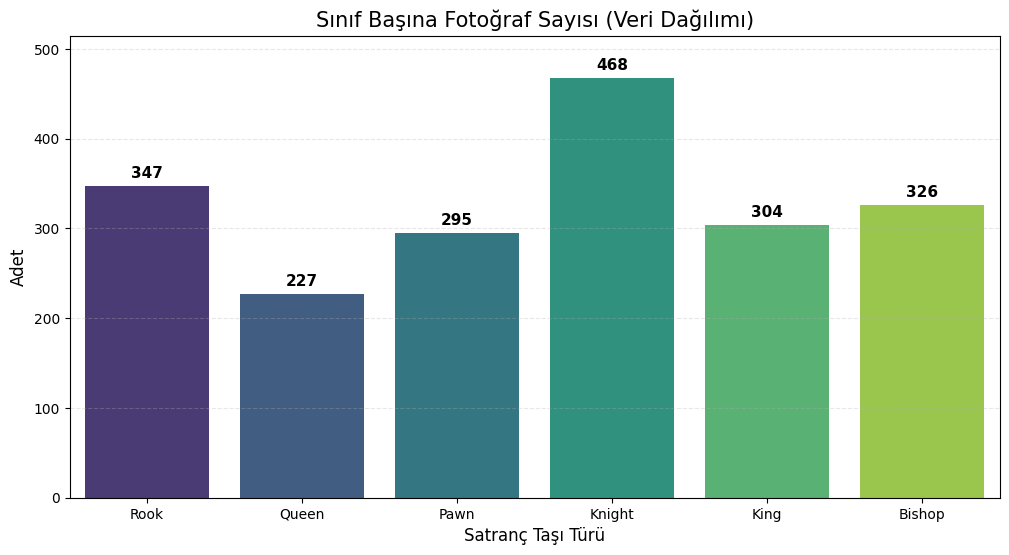

In [13]:
plt.figure(figsize=(12, 6))

# Grafiği oluştur
ax = sns.countplot(x='Sınıf', data=df, palette='viridis', order=CLASSES)

# Her sütunun üzerine verisini ekleyen döngü
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Sınıf Başına Fotoğraf Sayısı (Veri Dağılımı)', fontsize=15)
plt.xlabel('Satranç Taşı Türü', fontsize=12)
plt.ylabel('Adet', fontsize=12)
plt.ylim(0, df['Sınıf'].value_counts().max() * 1.1) # Sayıların sığması için tavanı yükselt
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

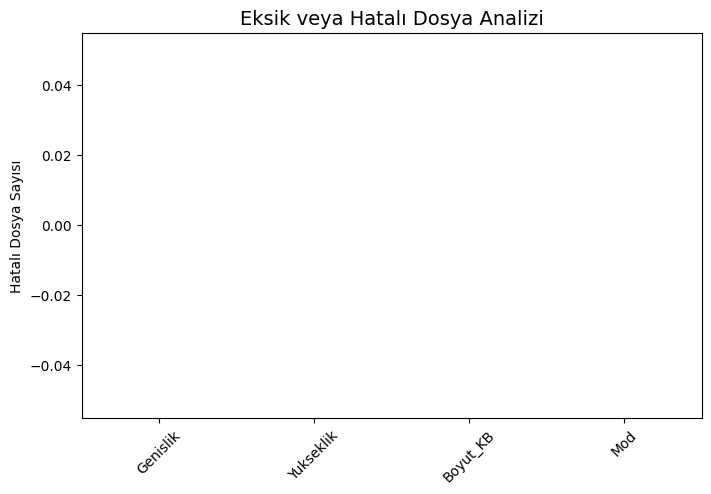

 Veri setinde okunmayan veya eksik dosya bulunamadı.


In [14]:
plt.figure(figsize=(8, 5))
missing_values = df.isnull().sum().drop(['Sınıf', 'Dosya_Adi'])
missing_values.plot(kind='bar', color='salmon')
plt.title('Eksik veya Hatalı Dosya Analizi', fontsize=14)
plt.ylabel('Hatalı Dosya Sayısı')
plt.xticks(rotation=45)
plt.show()

if missing_values.sum() == 0:
    print(" Veri setinde okunmayan veya eksik dosya bulunamadı.")
else:
    print(f"Toplam {missing_values.sum()} adet hatalı veri tespit edildi.")

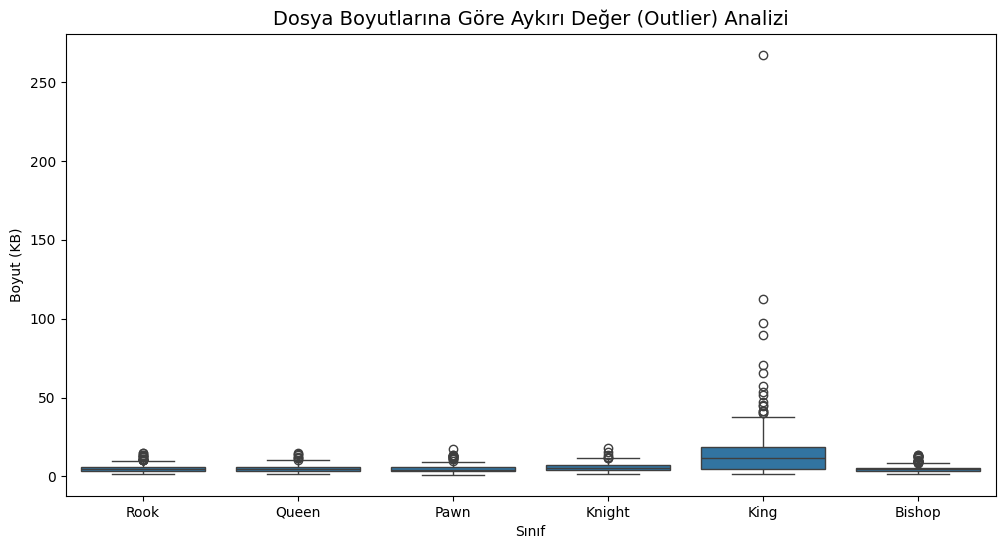

Yorum: Kutunun çok dışında kalan noktalar, diğer resimlerden aşırı büyük veya küçük dosyalardır.


In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Sınıf', y='Boyut_KB', data=df)
plt.title('Dosya Boyutlarına Göre Aykırı Değer (Outlier) Analizi', fontsize=14)
plt.ylabel('Boyut (KB)')
plt.show()

print("Yorum: Kutunun çok dışında kalan noktalar, diğer resimlerden aşırı büyük veya küçük dosyalardır.")

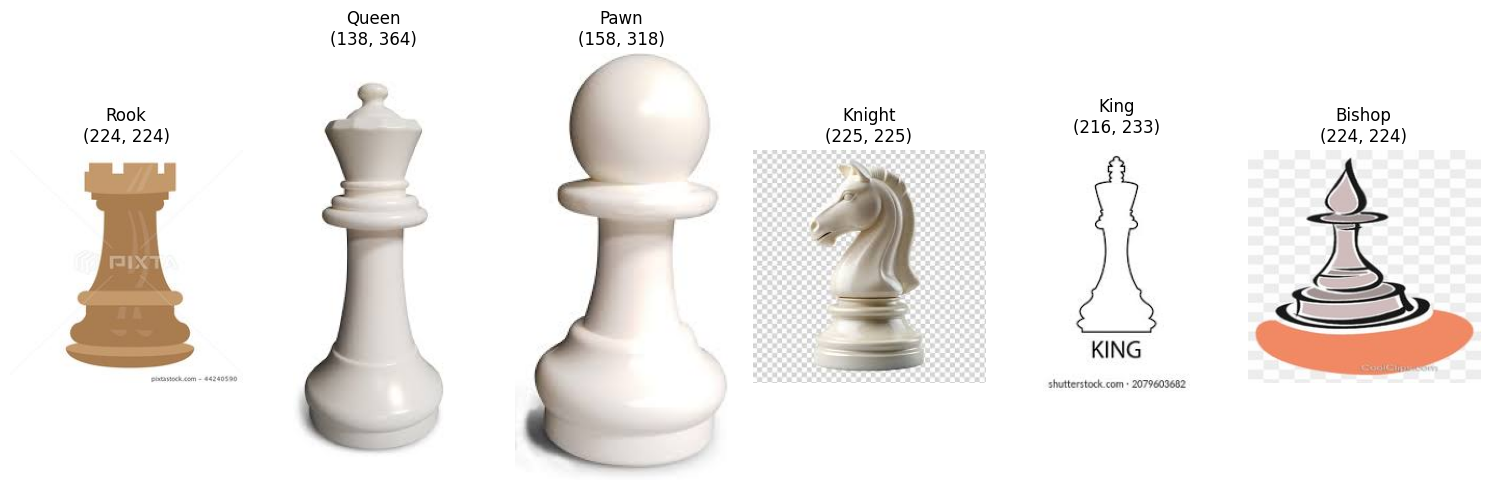

Örnek Resimler


In [16]:
plt.figure(figsize=(15, 5))
for i, c in enumerate(CLASSES):
    class_path = os.path.join(BASE_PATH, c)
    # Klasörden rastgele bir resim seç
    random_img = np.random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, random_img))
    
    plt.subplot(1, 6, i+1)
    plt.imshow(img)
    plt.title(f"{c}\n{img.size}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Örnek Resimler")

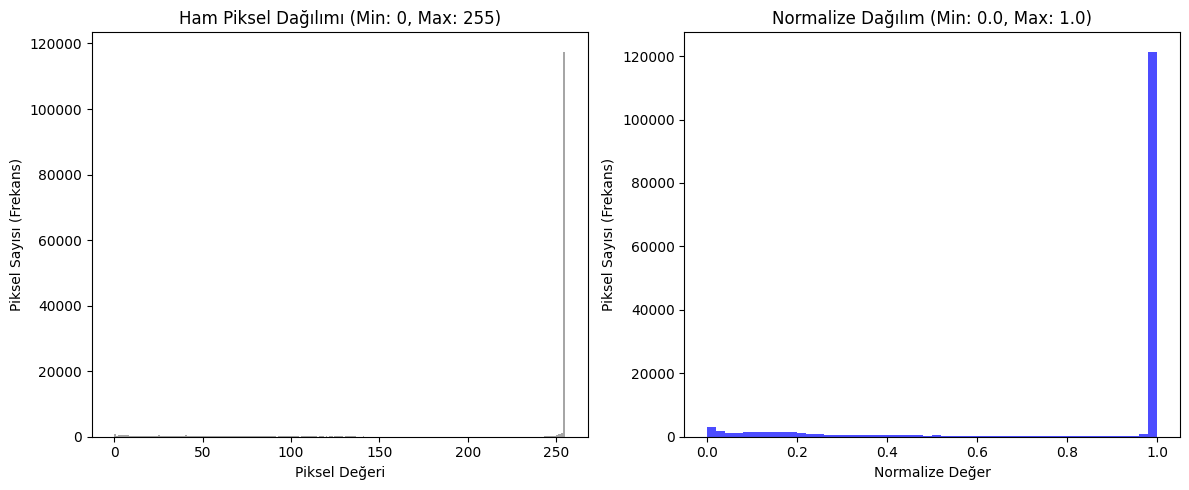

İşlem Özeti: Piksel değerleri 255'e bölünerek [0, 1] aralığına sıkıştırıldı.


In [17]:
# Rastgele bir resim seç ve oku
random_class = np.random.choice(CLASSES)
random_img_name = np.random.choice(os.listdir(os.path.join(BASE_PATH, random_class)))
img_path = os.path.join(BASE_PATH, random_class, random_img_name)

# Resmi aç ve diziye (array) çevir
img = Image.open(img_path).resize((224, 224))
img_array = np.array(img)

# NORMALİZASYON: 0-255 aralığını 0-1 aralığına çekiyoruz
img_normalized = img_array / 255.0

# Görselleştirme
plt.figure(figsize=(12, 5))

# Ham Veri Dağılımı
plt.subplot(1, 2, 1)
plt.hist(img_array.ravel(), bins=256, color='gray', alpha=0.7)
plt.title(f'Ham Piksel Dağılımı (Min: {img_array.min()}, Max: {img_array.max()})')
plt.xlabel('Piksel Değeri')
plt.ylabel('Piksel Sayısı (Frekans)')

# Normalize Veri Dağılımı
plt.subplot(1, 2, 2)
plt.hist(img_normalized.ravel(), bins=50, color='blue', alpha=0.7)
plt.title(f'Normalize Dağılım (Min: {img_normalized.min():.1f}, Max: {img_normalized.max():.1f})')
plt.xlabel('Normalize Değer')
plt.ylabel('Piksel Sayısı (Frekans)')

plt.tight_layout()
plt.show()

print("İşlem Özeti: Piksel değerleri 255'e bölünerek [0, 1] aralığına sıkıştırıldı.")

In [18]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Resmi okur, boyutlandırır ve normalize eder.
    """
    try:
        # 1. Resmi aç
        with Image.open(image_path) as img:
            # 2. RGB moduna çevir (şeffaf resimlerdeki hata payını önler)
            img = img.convert('RGB')
            # 3. Yeniden Boyutlandırma (Resizing)
            img = img.resize(target_size)
            # 4. Normalize Etme (0-1 aralığına çekme)
            img_arr = np.array(img) / 255.0
            return img_arr
    except Exception as e:
        return None

print("Ön işleme fonksiyonu hazır. Final aşamasında tüm veriler bu filtreden geçecek.")

Ön işleme fonksiyonu hazır. Final aşamasında tüm veriler bu filtreden geçecek.


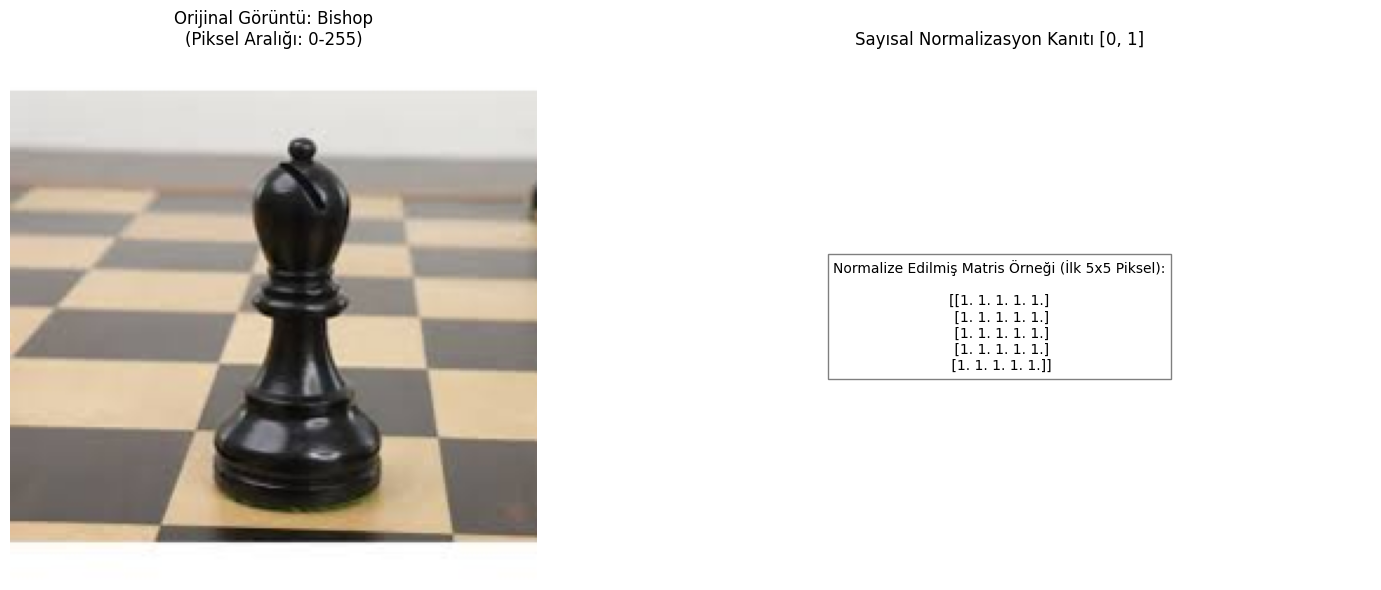

Seçilen taş: Bishop
Ham Piksel Örneği (0-255): 255
Normalize Piksel Örneği (0-1): 1.0000


In [20]:
# 1. Rastgele bir resim seç ve oku
random_class = np.random.choice(CLASSES)
class_path = os.path.join(BASE_PATH, random_class)
random_img_name = np.random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, random_img_name)

# 2. Resmi aç, RGB'ye çevir ve boyutlandır
img = Image.open(img_path).convert('RGB').resize((224, 224))
img_array = np.array(img)

# 3. Normalizasyon İşlemi
img_normalized = img_array / 255.0

# 4. Görselleştirme ve Sayısal Kanıt
plt.figure(figsize=(15, 6))

# Sol taraf: Orijinal Resim
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title(f"Orijinal Görüntü: {random_class}\n(Piksel Aralığı: {img_array.min()}-{img_array.max()})")
plt.axis('off')

# Sağ taraf: Normalize edilmiş halinin küçük bir parçasının (matris) gösterimi
plt.subplot(1, 2, 2)
plt.text(0.5, 0.5, f"Normalize Edilmiş Matris Örneği (İlk 5x5 Piksel):\n\n{img_normalized[:5, :5, 0]}", 
         fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
plt.title("Sayısal Normalizasyon Kanıtı [0, 1]")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Seçilen taş: {random_class}")
print(f"Ham Piksel Örneği (0-255): {img_array[0,0,0]}")
print(f"Normalize Piksel Örneği (0-1): {img_normalized[0,0,0]:.4f}")

In [21]:
from sklearn.model_selection import train_test_split

# Sınıflandırma için X (veriler) ve y (etiketler) yapısını hazırla
# Bu aşamada sadece mantığı gösteriyoruz
X = df['Dosya_Adi']
y = df['Sınıf']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim seti boyutu: {len(X_train)}")
print(f"Test seti boyutu: {len(X_test)}")

Eğitim seti boyutu: 1573
Test seti boyutu: 394
